In [1]:
using StatsBase
using Graphs
using SimpleWeightedGraphs
using GraphsMatching
using Plots

const ROOT = normpath(joinpath(@__DIR__, ".."))

include(joinpath(ROOT, "src", "circuits.jl"))
include(joinpath(ROOT, "src", "local.jl"))
include(joinpath(ROOT, "src", "main.jl"))
include(joinpath(ROOT, "src", "mwpm.jl"))


track_domains (generic function with 1 method)

In [2]:
horizontal_checks = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
                      0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
                      0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                      0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

vertical_checks = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
                    0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

horizontal_checks = Bool.(horizontal_checks)
vertical_checks = Bool.(circshift(vertical_checks, (1,0)))

println(length(detect_charges(horizontal_checks, vertical_checks)))

q = 0.02

for c in 0.0:0.25:1.0
    peff = q*(1-c)+c/2
    horizontal_checks2 = deepcopy(horizontal_checks)
    vertical_checks2 = deepcopy(vertical_checks)
    horizontal_checks3, vertical_checks3 = heal((horizontal_checks2, vertical_checks2), peff, q)
    domain = track_domains((horizontal_checks3, vertical_checks3))
    println(sum(domain))
end

# c = 1.0
# peff = q*(1-c)+c/2
# horizontal_checks2 = deepcopy(horizontal_checks)
# vertical_checks2 = deepcopy(vertical_checks)
# horizontal_checks3, vertical_checks3 = heal((horizontal_checks2, vertical_checks2), peff, q)
# domain = track_domains((horizontal_checks3, vertical_checks3))
# domain[4:11,5:12]

20
0
1
1
1
7


In [3]:
horizontal_checks = [0 0 0 0 1 0 0
                     0 0 0 0 1 0 0
                     0 1 1 0 0 0 0
                     0 0 0 0 0 1 0
                     0 1 0 0 0 0 0
                     0 0 1 0 1 1 0
                     0 0 0 0 0 0 0]

vertical_checks = [0 0 0 0 0 0 0
                   0 1 0 1 1 0 0
                   0 0 0 0 0 1 0
                   0 0 1 0 0 0 0
                   0 1 0 0 0 1 0
                   0 0 0 0 0 1 0
                   0 0 0 0 0 0 0]

function pad_square(M::AbstractMatrix, x::Int)
    rows, cols = size(M)
    new_rows = rows + 2 * x
    new_cols = cols + 2 * x
    new_M = zeros(Bool, new_rows, new_cols)
    new_M[x+1:x+rows, x+1:x+cols] = M
    return new_M
end


horizontal_checks = pad_square(horizontal_checks, 7)
vertical_checks = pad_square(vertical_checks, 7)

println(length(detect_charges(horizontal_checks, vertical_checks)))
println()

q = 0.05

for c in 0.0:0.1:1.0
    peff = q*(1-c)+c/2
    horizontal_checks2 = deepcopy(horizontal_checks)
    vertical_checks2 = deepcopy(vertical_checks)
    horizontal_checks3, vertical_checks3 = heal((horizontal_checks2, vertical_checks2), peff, q)
    domain = track_domains((horizontal_checks3, vertical_checks3))
    println(sum(domain))
end


12

1
1
1
1
1
3
3
10
10
6
8


10



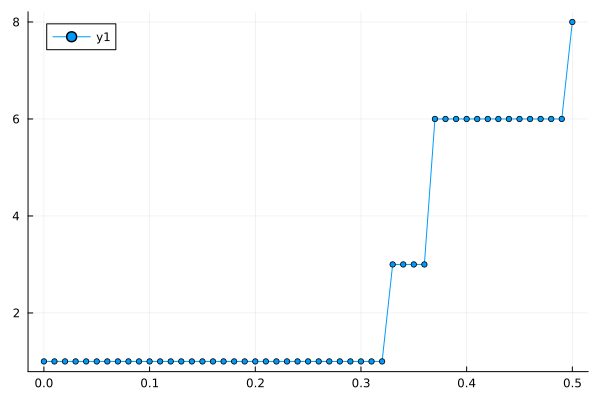

In [10]:
horizontal_checks = [0 0 0 0 1 0 0
                     0 0 0 0 1 0 0
                     0 1 1 0 0 0 0
                     0 0 0 0 0 1 0
                     0 1 0 0 0 0 0
                     0 0 0 0 1 1 0
                     0 0 0 0 0 0 0]

vertical_checks = [0 0 0 0 0 0 0
                   0 1 0 1 1 0 0
                   0 0 0 0 0 1 0
                   0 0 1 0 0 0 0
                   1 0 0 0 0 1 0
                   0 0 0 0 0 1 0
                   0 0 0 0 0 0 0]

function pad_square(M::AbstractMatrix, x::Int)
    rows, cols = size(M)
    new_rows = rows + 2 * x
    new_cols = cols + 2 * x
    new_M = zeros(Bool, new_rows, new_cols)
    new_M[x+1:x+rows, x+1:x+cols] = M
    return new_M
end


horizontal_checks = pad_square(horizontal_checks, 7)
vertical_checks = pad_square(vertical_checks, 7)

println(length(detect_charges(horizontal_checks, vertical_checks)))
println()

q = 0.1

counts = Int[]

for peff in 0.0:0.01:0.5
    horizontal_checks2 = deepcopy(horizontal_checks)
    vertical_checks2 = deepcopy(vertical_checks)
    horizontal_checks3, vertical_checks3 = heal((horizontal_checks2, vertical_checks2), peff, q)
    domain = track_domains((horizontal_checks3, vertical_checks3))
    push!(counts, sum(domain))
end

plot(0.0:0.01:0.5, counts, m=3)

8



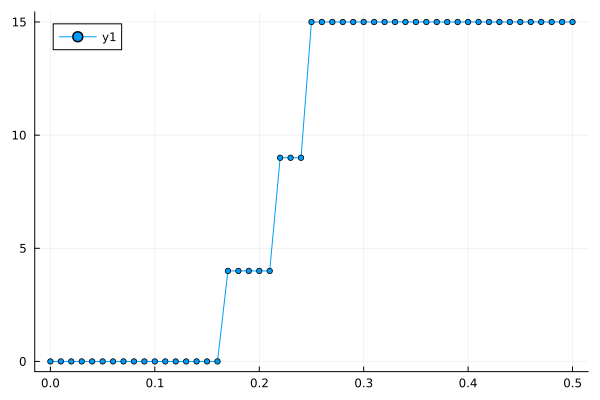

In [60]:
# horizontal_checks = [0 1 1 0 0 0 0 0
#                      0 0 0 1 1 0 1 0
#                      0 1 1 0 1 1 0 0
#                      0 0 0 0 1 0 0 0
#                      0 0 0 1 1 1 1 0
#                      0 0 0 0 0 0 0 0
#                      0 0 0 0 0 0 0 0
#                      0 0 0 0 0 0 0 0]

# vertical_checks = [0 0 0 0 0 0 0 0
#                    1 0 1 0 0 0 0 0
#                    1 0 0 0 1 1 1 0
#                    0 0 1 1 1 0 1 0
#                    0 0 1 0 0 0 1 0
#                    0 0 0 0 0 0 0 0
#                    0 0 0 0 0 0 0 0
#                    0 0 0 0 0 0 0 0]


horizontal_checks = [0 1 1 0 0 0 0 0
                     0 0 0 0 1 0 1 0
                     0 1 1 0 0 1 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 1 1 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0
                     0 0 0 0 0 0 0 0]

vertical_checks = [0 0 0 0 0 0 0 0
                   1 0 1 0 0 0 0 0
                   1 0 0 0 1 1 1 0
                   0 0 1 0 1 0 0 0
                   0 0 1 0 0 0 1 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0
                   0 0 0 0 0 0 0 0]

# horizontal_diff = rand(8, 8) .< 0.15
# vertical_diff = rand(8, 8) .< 0.15

# horizontal_checks = horizontal_checks .⊻ horizontal_diff
# vertical_checks = vertical_checks .⊻ vertical_diff


function pad_square(M::AbstractMatrix, x::Int)
    rows, cols = size(M)
    new_rows = rows + 2 * x
    new_cols = cols + 2 * x
    new_M = zeros(Bool, new_rows, new_cols)
    new_M[x+1:x+rows, x+1:x+cols] = M
    return new_M
end


horizontal_checks = pad_square(horizontal_checks, 7)
vertical_checks = pad_square(vertical_checks, 7)

println(length(detect_charges(horizontal_checks, vertical_checks)))
println()

q = 0.1

counts = Int[]

for peff in 0.0:0.01:0.5
    horizontal_checks2 = deepcopy(horizontal_checks)
    vertical_checks2 = deepcopy(vertical_checks)
    horizontal_checks3, vertical_checks3 = heal((horizontal_checks2, vertical_checks2), peff, q)
    domain = track_domains((horizontal_checks3, vertical_checks3))
    push!(counts, sum(domain))
end

plot(0.0:0.01:0.5, counts, m=3)

In [56]:
peff = 0.5
    horizontal_checks2 = deepcopy(horizontal_checks)
    vertical_checks2 = deepcopy(vertical_checks)
    horizontal_checks3, vertical_checks3 = heal((horizontal_checks2, vertical_checks2), peff, q)
    domain = track_domains((horizontal_checks3, vertical_checks3))
    push!(counts, sum(domain))


domain[8:16, 8:16]

9×9 Matrix{Bool}:
 0  0  0  0  0  0  0  0  0
 0  1  1  0  0  0  0  0  0
 0  1  1  1  1  0  1  0  0
 0  0  0  1  1  1  1  0  0
 0  0  0  1  1  1  1  0  0
 0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0

In [44]:
horizontal_checks[8:16, 8:16]

9×9 Matrix{Bool}:
 0  1  1  0  1  0  0  0  0
 0  1  0  1  0  0  0  0  0
 0  1  0  0  1  0  0  0  0
 0  1  0  0  1  1  0  0  0
 0  1  0  1  1  1  1  0  0
 0  0  0  0  0  0  1  0  0
 0  0  0  0  0  0  1  0  0
 0  0  1  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0

6



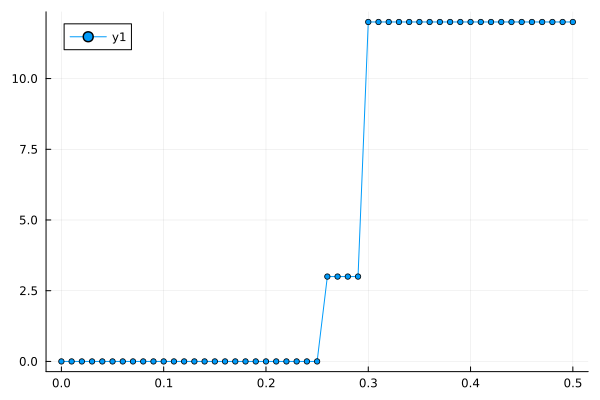

In [30]:
horizontal_checks = [0 0 0 0 0 0 0
                     0 0 0 0 0 0 0
                     0 1 1 0 0 0 0
                     0 0 0 1 0 1 1
                     0 1 0 0 0 0 0
                     0 0 0 1 0 0 1
                     0 0 0 0 0 0 0]

vertical_checks = [0 0 0 0 0 0 0
                   0 0 0 0 0 0 0
                   0 0 0 0 0 0 0
                   1 0 1 0 0 0 0
                   1 0 0 0 0 0 1
                   0 0 0 0 0 0 1
                   0 0 0 0 0 0 0]

function pad_square(M::AbstractMatrix, x::Int)
    rows, cols = size(M)
    new_rows = rows + 2 * x
    new_cols = cols + 2 * x
    new_M = zeros(Bool, new_rows, new_cols)
    new_M[x+1:x+rows, x+1:x+cols] = M
    return new_M
end


horizontal_checks = pad_square(horizontal_checks, 7)
vertical_checks = pad_square(vertical_checks, 7)

println(length(detect_charges(horizontal_checks, vertical_checks)))
println()

q = 0.1

counts = Int[]

for peff in 0.0:0.01:0.5
    horizontal_checks2 = deepcopy(horizontal_checks)
    vertical_checks2 = deepcopy(vertical_checks)
    horizontal_checks3, vertical_checks3 = heal((horizontal_checks2, vertical_checks2), peff, q)
    domain = track_domains((horizontal_checks3, vertical_checks3))
    push!(counts, sum(domain))
end

plot(0.0:0.01:0.5, counts, m=3)

In [5]:
horizontal_checks = [0 0 0 0 1 0 0
                     0 0 0 0 1 0 0
                     0 1 1 0 0 0 0
                     0 0 0 0 0 1 0
                     0 1 0 0 0 0 0
                     0 0 1 0 1 1 0
                     0 0 0 0 0 0 0]

vertical_checks = [0 0 0 0 0 0 0
                   0 1 0 1 1 0 0
                   0 0 0 0 0 1 0
                   0 0 1 0 0 0 0
                   0 1 0 0 0 1 0
                   0 0 0 0 0 1 0
                   0 0 0 0 0 0 0]

function pad_square(M::AbstractMatrix, x::Int)
    rows, cols = size(M)
    new_rows = rows + 2 * x
    new_cols = cols + 2 * x
    new_M = zeros(Bool, new_rows, new_cols)
    new_M[x+1:x+rows, x+1:x+cols] = M
    return new_M
end

function unpad(M::AbstractMatrix, x::Int)
    rows, cols = size(M)
    return M[x+1:x+rows-2*x, x+1:x+cols-2*x]
end

x = 7

horizontal_checks = pad_square(horizontal_checks, x)
vertical_checks = pad_square(vertical_checks, x)

println(length(detect_charges(horizontal_checks, vertical_checks)))
println()

q = 0.05

peff = 0.455
horizontal_checks2 = deepcopy(horizontal_checks)
vertical_checks2 = deepcopy(vertical_checks)
horizontal_checks3, vertical_checks3 = heal((horizontal_checks2, vertical_checks2), peff, q)
domain = track_domains((horizontal_checks3, vertical_checks3))

unpad(domain, x)

12



7×7 Matrix{Bool}:
 0  0  0  0  0  0  0
 0  0  0  0  1  0  0
 0  0  0  0  0  0  0
 0  1  1  0  0  0  0
 0  1  0  0  0  1  0
 0  0  0  0  0  1  0
 0  0  0  0  0  0  0

In [157]:
weight(peff, q, true)

2.7639506034541466

In [150]:
peff

0.455

In [50]:
horizontal_checks = [0 0 0 0
                     0 0 1 0
                     0 0 1 0
                     0 0 0 0]

vertical_checks = [0 0 0 0
                   0 0 0 0
                   0 1 1 0
                   0 0 0 0]


detect_charges(horizontal_checks, vertical_checks)

Tuple{Int64, Int64}[]

In [56]:
ρ = [0 0 0 0 
     0 0 1 0
     0 0 0 0
     0 0 0 0]
measure(ρ, 0.0)

([0 0 1 0; 0 0 1 0; 0 0 0 0; 0 0 0 0], [0 0 0 0; 0 1 1 0; 0 0 0 0; 0 0 0 0])

In [52]:
circshift(vertical_checks, (1,0))

4×4 Matrix{Int64}:
 0  0  0  0
 0  0  0  0
 0  0  0  0
 0  1  1  0

In [16]:
L = 8
p = 0.1
q = 0.1
ρ = initialstate(L)
ρ = noiselayer(ρ, p)
horizontal_checks, vertical_checks = measure(ρ, q)

(Bool[1 1 … 0 0; 0 0 … 1 0; … ; 1 1 … 0 0; 1 0 … 0 0], Bool[0 1 … 0 1; 0 0 … 1 0; … ; 1 0 … 1 1; 1 1 … 0 0])

In [19]:
peff = 0.2
healed_horizontal, healed_vertical = heal((horizontal_checks, vertical_checks), peff, q)
domain = track_domains((healed_horizontal, healed_vertical))
if magnetization(domain) > 0.5
    domain = .!domain
end

8×8 BitMatrix:
 1  1  1  1  0  0  0  0
 0  0  0  1  1  0  0  0
 0  0  0  0  1  1  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0
 1  0  0  0  0  0  0  0
 0  1  0  0  0  0  0  0

In [20]:
ρ

8×8 BitMatrix:
 1  1  0  0  0  0  0  0
 0  0  1  0  1  0  1  0
 0  0  1  0  1  1  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0
 1  0  0  0  0  0  0  0
 0  1  0  0  0  0  0  0